## Example 4a:
Exploration of how both the theoretical uncertainty limit and the predicted uncertainty vary with bead size.

In [1]:
import logging
import math
import warnings

import numpy as np
import torch
import pytorch_lightning as pl
from lightning_fabric.utilities.warnings import PossibleUserWarning
from matplotlib import pyplot

In [2]:
# Silence a few nuisance warnings:
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=PossibleUserWarning)
warnings.filterwarnings("ignore", message="Starting from v1.9.0, `tensorboardX`")
warnings.filterwarnings("ignore", message=r".*isinstance\(treespec, LeafSpec\).*")

In [3]:
from cynosure.config_defaults import (
    get_default_training_config,
    get_default_simulation_config,
    get_default_optical_config,
    get_default_phase_config,
    get_default_amplitude_config,
    get_default_phase_prior,
    get_default_amplitude_prior,
    get_default_noise_config,
    get_default_mixture_config,
    get_default_velocity_config,
    get_default_blob_prior,
)
from cynosure.information.fisher_information import calculate_fisher_matrix, calculate_van_trees_bounds
from cynosure.object_distribution import FixedBead, SampledKBlobs
from cynosure.utilities.training_utils import NoValidationBar
from cynosure.zstack_decoding import ZstackSolver_MixedDensity
from cynosure.zstack_decoding.stack_simulator import StackSimulator

#### van Trees limit at different bead sizes

The fundamental uncertainty limit can be calculated for different bead sizes from just the forwards model (no fitting required).

In [4]:
train_cfg = get_default_training_config(learning_rate=0.5e-3)
sim_cfg = get_default_simulation_config()
opt_cfg = get_default_optical_config()
phase_cfg = get_default_phase_config()
amp_cfg = get_default_amplitude_config()
phase_prior = get_default_phase_prior()
amp_prior = get_default_amplitude_prior()
noise_cfg = get_default_noise_config(
    min_photons=10_000,
    max_photons=10_000,
    max_background=0,
)
vel_cfg = get_default_velocity_config()

object_distrib = FixedBead(sim_cfg, bead_diameter=0.1)
mixture_cfg = get_default_mixture_config()

In [5]:
rng_seed = 123
z_jitter = 1.5  # um
device = "cuda" if torch.cuda.is_available() else "cpu"

pl.seed_everything(rng_seed, workers=True)
solver = ZstackSolver_MixedDensity(
    train_cfg=train_cfg,
    sim_cfg=sim_cfg,
    optics_cfg=opt_cfg,
    phase_cfg=phase_cfg,
    amp_cfg=amp_cfg,
    phase_prior_cfg=phase_prior,
    amp_prior_cfg=amp_prior,
    object_distribution=object_distrib,
    z_objective=torch.zeros(1),
    z_jitter=z_jitter,
    mixture_cfg=mixture_cfg,
    noise_cfg=noise_cfg,
    hidden_channels=(32, 64),
    embedding_dims=128,
)
solver = solver.to(device)

Seed set to 123


In [6]:
batch_size = 64
z_max = 1.5
num_z = 19

bead_diameter_list = np.linspace(0.2, 1.0, 3)  # diameters to titrate over

In [7]:
gen = torch.Generator(device=device).manual_seed(123)
z = torch.linspace(-z_max, z_max, num_z, device=device)
phase_coefs, amp_coefs = solver.simulator.sample_coefficients(batch_size, generator=gen)

As usual, the Jacobians mean this next step will take a couple minutes...

In [8]:
coefs = solver.coefficients.gather_nonpinned(solver.coefficients.join(phase_coefs, amp_coefs)).to(device)  # [B, C_kept]
num_coefs = solver.coefficients.num_nonpinned_coefs

van_trees_by_diam = {}

for diam in bead_diameter_list:
    sim = StackSimulator.from_configs(
        sim_cfg=sim_cfg,
        optics_cfg=opt_cfg,
        phase_cfg=phase_cfg,
        amp_cfg=amp_cfg,
        phase_prior_cfg=phase_prior,
        amp_prior_cfg=amp_prior,
        object_distribution=FixedBead(sim_cfg, bead_diameter=diam),
        noise_cfg=noise_cfg,
    ).to(device)

    fisher_matrix_samples = []
    for coefs_i in coefs:
        _, fisher_matrix = calculate_fisher_matrix(coefs_i, z, sim)
        fisher_matrix_samples.append(fisher_matrix.numpy(force=True))
    fisher_matrix_samples = np.concatenate(fisher_matrix_samples)
    fisher_matrix_samples = fisher_matrix_samples.reshape(batch_size, z.shape[0], num_coefs, num_coefs)  # [B, Z, C_kept, C_kept]
    fisher_matrix = fisher_matrix_samples.mean(0)  # [Z, C_kept, C_kept]

    prior_sigmas = solver.coefficients.target_scales[~solver.coefficients.is_pinned].numpy(force=True)
    prior_covariance = np.diag(prior_sigmas)**2
    van_trees = calculate_van_trees_bounds(fisher_matrix, prior_covariance)  # [Z, C_kept]
    van_trees_by_diam[diam] = van_trees

As the bead gets larger, aberrations become fundamentally harder to determine, since convolution with the bead washes out the fine structure that distinguishes different aberrations. You'd expect a similar phenomenon if your camera's pixels were too coarse, since you're doing a similar type of convolution.

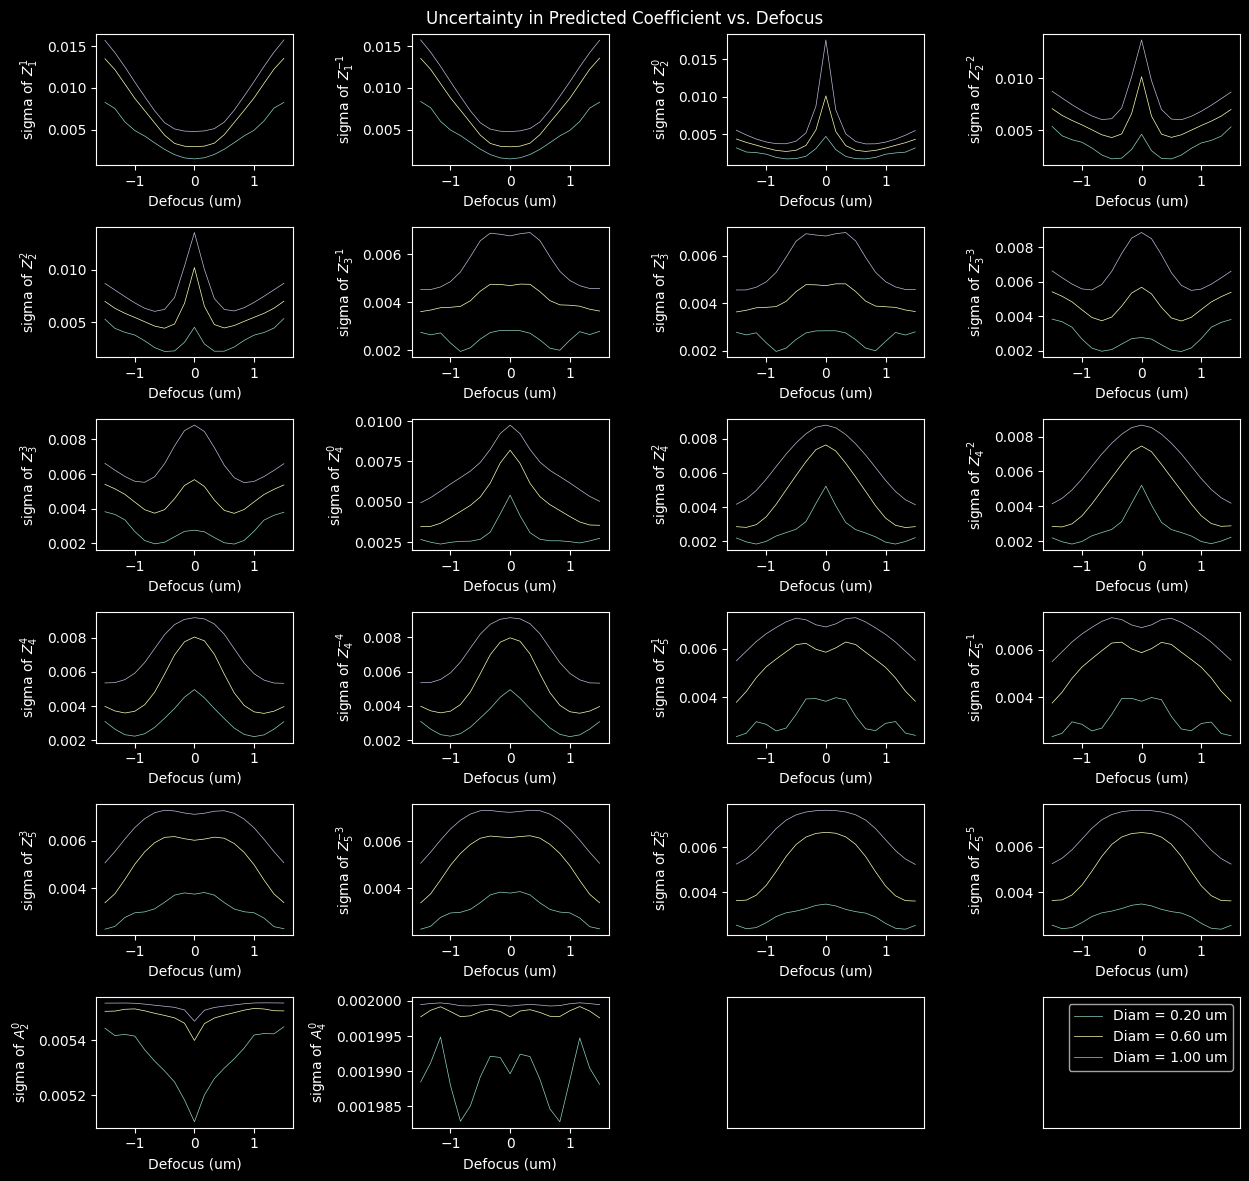

In [9]:
num_cols = 4
panel_size = 3
aspect_ratio = 0.7

labels = solver.coefficients.nonpinned_labels
handles = []
handle_labels = []

num_rows = int(math.ceil(num_coefs / num_cols))
figsize = (panel_size * aspect_ratio * num_rows, panel_size * num_cols)
fig, axarr = pyplot.subplots(num_rows, num_cols, figsize=figsize)

for diam in bead_diameter_list:
    van_trees = van_trees_by_diam[diam]
    for i, ax in enumerate(axarr.ravel()):
        if i < num_coefs:
            ln, = ax.plot(z.numpy(force=True), van_trees[:, i], lw=0.5)
            ax.set_ylabel(f"sigma of {labels[i]}")
            ax.set_xlabel("Defocus (um)")
            if i == 0:
                handles.append(ln)
                handle_labels.append(f'Diam = {diam:.2f} um')
        else:
            ax.set_xticks([])
            ax.set_yticks([])

axarr[-1, -1].legend(handles=handles, labels=handle_labels)
fig.suptitle("Uncertainty in Predicted Coefficient vs. Defocus")
fig.tight_layout()

#### Model performance with different bead sizes

Now let's see if the model can learn to reproduce this dependence.

First, train the model to simultaneously learn the aberrations and a randomly-sampled bead size. Same solver config as before, just with a variable-diameter bead instead of a fixed one.

In [10]:
blob_cfg = get_default_blob_prior(
    position_sigma=1e-6,
    reference_diameter=0.6,
    log_diameter_sigma=0.3,
)  # keep centered, only vary size

variable_object_distrib = SampledKBlobs(sim_cfg, num_blobs=1, prior_cfg=blob_cfg)
mixture_cfg = get_default_mixture_config()

In [11]:
pl.seed_everything(rng_seed, workers=True)
solver = ZstackSolver_MixedDensity(
    train_cfg=train_cfg,
    sim_cfg=sim_cfg,
    optics_cfg=opt_cfg,
    phase_cfg=phase_cfg,
    amp_cfg=amp_cfg,
    phase_prior_cfg=phase_prior,
    amp_prior_cfg=amp_prior,
    object_distribution=variable_object_distrib,
    z_objective=torch.zeros(1),
    z_jitter=z_jitter,
    mixture_cfg=mixture_cfg,
    noise_cfg=noise_cfg,
    hidden_channels=(32, 64),
    embedding_dims=128,
)
solver = solver.to(device)

Seed set to 123


In [12]:
trainer = pl.Trainer(
    max_epochs=1000,  # much longer than usual, to tighten the bounds
    accelerator=device,
    log_every_n_steps=100,
    callbacks=[NoValidationBar()],
    gradient_clip_val=1.0,
)
trainer.fit(solver)
solver = solver.eval()

In [13]:
"""
Training takes a while to make the uncertainty bounds nice and snug.
Once it's done, uncomment this to load the checkpoint from wherever it saved to save some time.
"""
# checkpoint = torch.load("./VarBeadSize_1000epochs/checkpoints/final.ckpt", weights_only=True)
# solver.load_state_dict(checkpoint["state_dict"])
# solver = solver.to(device).eval()

Do the usual sanity check by generating a batch of examples, decoding and re-inferring, and plotting the ground truth against the predicted reconstructions.

In [14]:
batch_size = 4
num_samples = 16
with torch.inference_mode():
    images, phase_coefs, amp_coefs, object_params = solver.simulator.create_examples(batch_size)
    pred_phase_coefs, pred_amp_coefs, pred_object_params = solver.predict_samples(images, num_samples)
    pred_objects = solver.object_distribution.render_from_params(pred_object_params.reshape(batch_size * num_samples, -1))
    pred_images = solver.simulator.simulate_normalized_stacks(
        pred_phase_coefs.reshape(batch_size*num_samples, -1),
        pred_amp_coefs.reshape(batch_size*num_samples, -1),
        objects=pred_objects,
    ).unflatten(0, (batch_size, num_samples))  # [batch_size, num_samples, num_z, H, W]

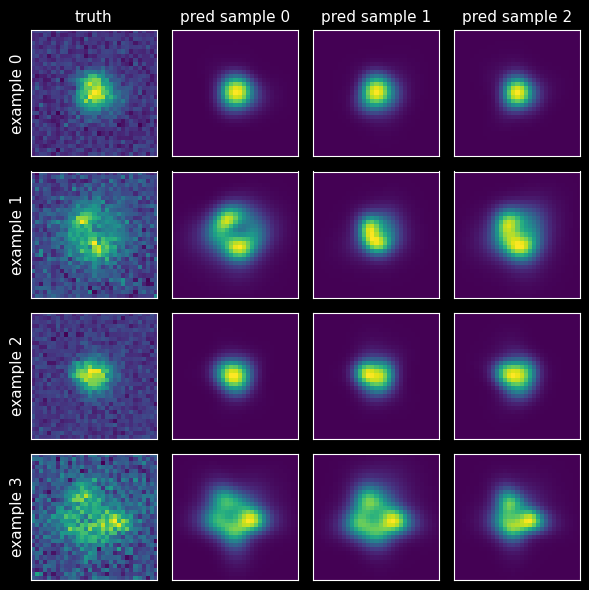

In [15]:
num_samples_to_show = 3
panel_size = 2
fig, axarr = pyplot.subplots(batch_size, 1+num_samples_to_show, figsize=(num_samples_to_show*panel_size, num_samples_to_show*panel_size))
for bidx in range(batch_size):
    axarr[bidx, 0].imshow(images[bidx, 0].numpy(force=True))
    for i in range(num_samples_to_show):
        axarr[bidx, i+1].imshow(pred_images[bidx, i, 0].numpy(force=True))

for ax in axarr.ravel():
    ax.set_xticks([])
    ax.set_yticks([])
for bidx in range(batch_size):
    axarr[bidx, 0].set_ylabel(f"example {bidx}", size=11)
axarr[0, 0].set_title("truth", size=11)
for i in range(num_samples_to_show):
    axarr[0, i+1].set_title(f"pred sample {i}", size=11)
fig.tight_layout()

Simulate images with each of a range of bead sizes, and store the predicted uncertainty per coefficient, z, and bead diameter.

In [16]:
batch_size = 64
solver = solver.to(device).eval()
phase_coefs, amp_coefs = solver.simulator.sample_coefficients(batch_size)

In [17]:
z_exp = z.unsqueeze(0).expand((batch_size, num_z)).reshape(batch_size*num_z)
defocus_exp = solver.propagator.defocus_from_objective_z(z_exp)
phase_coefs_exp = phase_coefs.unsqueeze(1).expand((batch_size, num_z, -1)).reshape(batch_size*num_z, -1)
amp_coefs_exp = amp_coefs.unsqueeze(1).expand((batch_size, num_z, -1)).reshape(batch_size*num_z, -1)

In [18]:
sigma_by_diam = {}
with torch.inference_mode():
    for j, diam in enumerate(bead_diameter_list):

        fixed_bead = FixedBead(sim_cfg, bead_diameter=diam).to(solver.device)
        obj = fixed_bead.sample(batch_size*num_z)

        images = solver.simulator.simulate_stacks(defocus_exp, phase_coefs_exp, amp_coefs_exp, obj)
        images = solver.simulator.apply_noise(images)
        images = solver.simulator.normalize_stack(images)
        mixture_family = solver.predict_distribution(images)

        mixture = mixture_family.mixture_distribution
        dist = mixture_family.component_distribution

        covariances = dist.covariance_matrix
        sigmas = covariances.diagonal(dim1=-2, dim2=-1).sqrt()
        sigmas = sigmas.reshape(batch_size, num_z, solver.num_components, -1)  # [B, Z, num_components, num_coefficients]
        sigma_by_diam[diam] = sigmas.numpy(force=True)

Plot the average predicted uncertainty (solid) and the van Trees limit (dashed) as a function of z for each bead diameter.

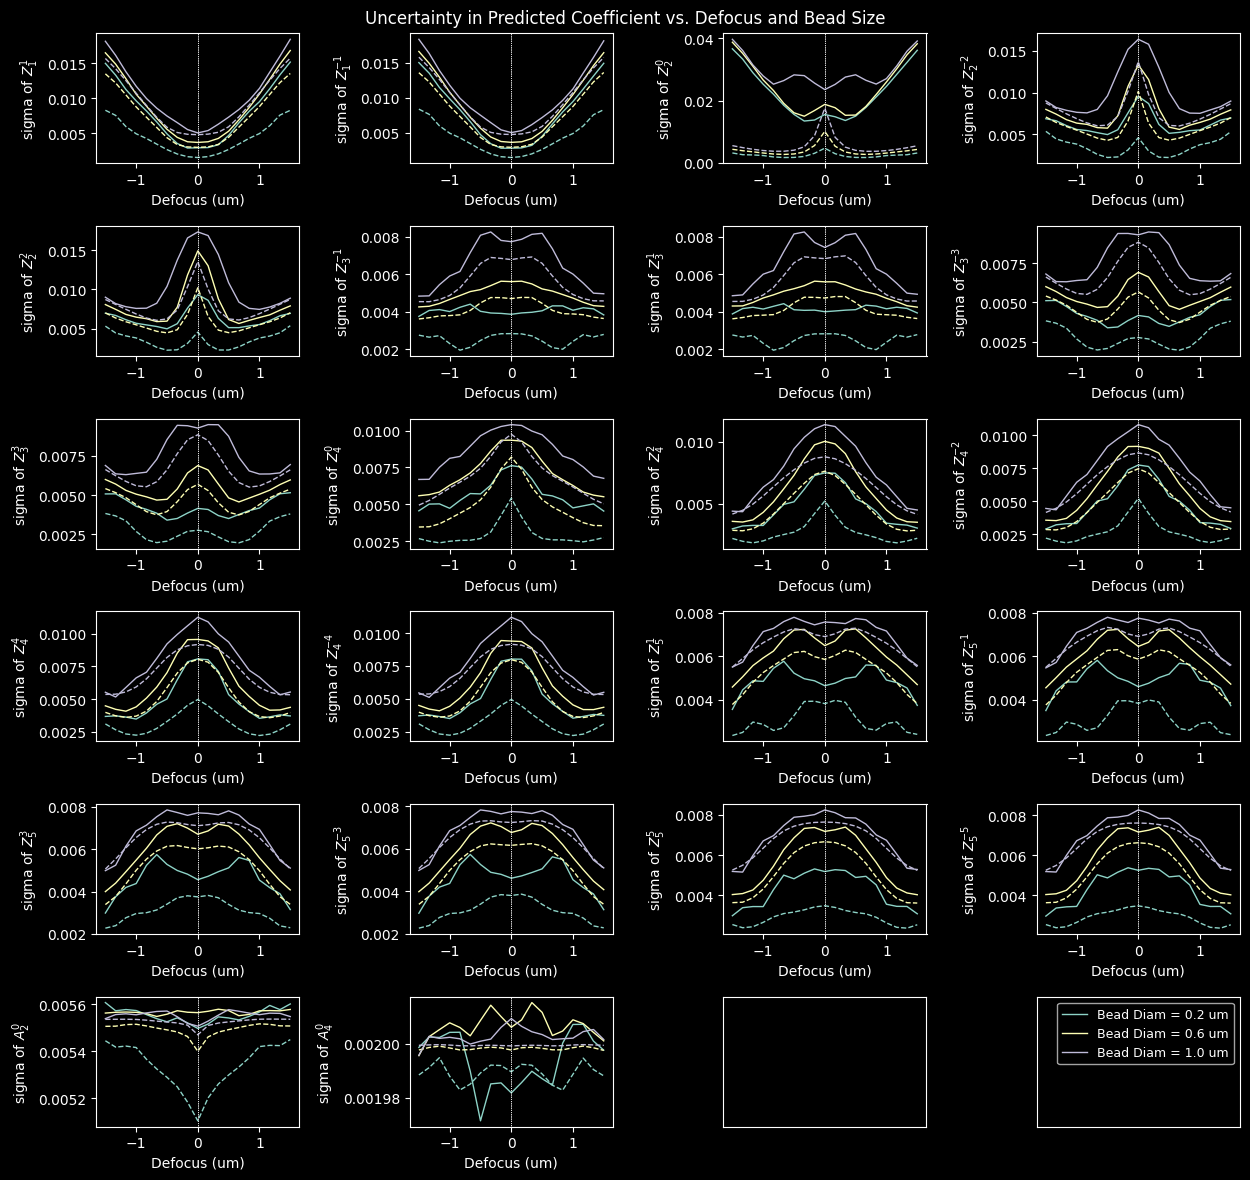

In [19]:
num_cols = 4
panel_size = 3
aspect_ratio = 0.7

num_rows = int(math.ceil(num_coefs / num_cols))
figsize = (panel_size * aspect_ratio * num_rows, panel_size * num_cols)
labels = solver.coefficients.nonpinned_labels
handles = []
handle_labels = []

fig, axarr = pyplot.subplots(num_rows, num_cols, figsize=figsize)
for j, diam in enumerate(bead_diameter_list):
    for i, ax in enumerate(axarr.ravel()):
        if i < num_coefs:
            s = sigma_by_diam[diam][:, :, :, i].mean((0, 2))
            ln, = ax.plot(z.numpy(force=True), s, lw=1, color=f"C{j}")

            vt = van_trees_by_diam[diam][:, i]
            ax.plot(z.numpy(force=True), vt, ls="--", lw=1, color=f"C{j}")

            if i == 0:
                handles.append(ln)
                handle_labels.append(f'Bead Diam = {diam:.1f} um')
            ax.set_ylabel(f"sigma of {labels[i]}")
            ax.set_xlabel("Defocus (um)")
            ax.axvline(0, ls=":", lw=0.5)
        else:
            ax.set_xticks([])
            ax.set_yticks([])

axarr[-1, -1].legend(handles=handles, labels=handle_labels, fontsize=9)
fig.suptitle("Uncertainty in Predicted Coefficient vs. Defocus and Bead Size")
fig.tight_layout()

Trends seem to broadly hold. Predictions are a bit less tight against the theoretical limits than in example 3a, possibly because we're requiring the model to learn an additional degree of freedom.

As seen in previous examples, predicted uncertainties for $Z_2^0$ never really match the van Trees bound, and the amplitude terms don't have much room between the prior and the van Trees limit anyway. The other low-$n$ coefficients generally do pretty well, and in particular, successfully capture the dependence on the bead diameter and much of the finer dependence on z. Agreement degrades for higher-order aberrations, likely for the reasons mentioned earlier (note that even the smaller bead size plotted here is somewhat larger than the one used in example 3a; this was done as a convenience to ensure all three bead sizes here were in the log-normal training domain).